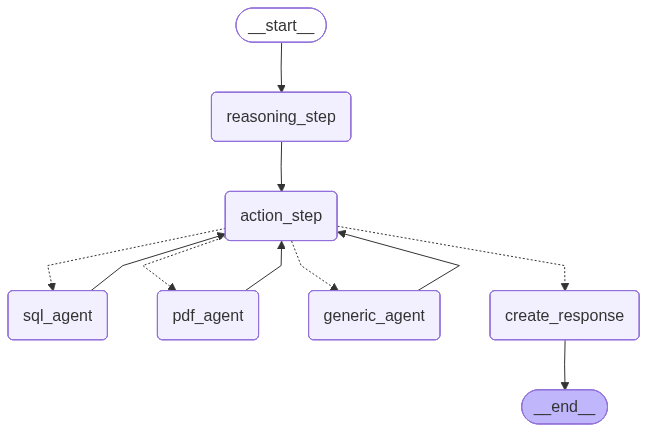

In [4]:
from __future__ import annotations

import operator
from typing import Any, Dict, List, Literal, Optional
from typing_extensions import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Optional (when you hook up planning to an LLM)
# from langchain_openai import ChatOpenAI
# from langchain_core.messages import SystemMessage, HumanMessage

# -------------------------
# State (with reducers)
# -------------------------
class GraphState(TypedDict):
    user_query: str

    # Accumulate plan steps and tool runs across iterations
    planning_steps: Annotated[List[str], operator.add]
    tool_runs: Annotated[List[Dict[str, Any]], operator.add]

    # Collect answers/snippets to synthesize later
    answers: Annotated[List[str], operator.add]

    # Control flags / routing hints
    selected_tool: Optional[str]         # "sql_agent" | "pdf_agent" | "generic_agent" | "done"
    satisfied: bool

    # Final output
    final_response: Optional[str]

# -------------------------
# Nodes (placeholders)
# -------------------------
def reasoning_step(state: GraphState) -> Dict:
    """Plan the approach. (Stub: add your LLM planning later)"""
    steps = [
        "Understand intent & constraints",
        "Choose an appropriate tool (sql/pdf/generic)",
        "Run tool(s) and collect evidence",
        "Check sufficiency; if not, iterate",
        "Synthesize and respond",
    ]
    return {"planning_steps": steps}

def action_step(state: GraphState) -> Dict:
    """Pick the next tool or mark as done."""
    q = state["user_query"].lower()

    if state.get("satisfied"):
        return {"selected_tool": "done"}

    # Super-naive router (replace with your own policy/LLM router)
    if "pdf" in q or "document" in q:
        tool = "pdf_agent"
    elif any(k in q for k in ["sql", "query", "database", ".db"]):
        tool = "sql_agent"
    else:
        tool = "generic_agent"

    return {"selected_tool": tool}

def route_action(state: GraphState) -> Literal["sql_agent","pdf_agent","generic_agent","create_response"]:
    """Conditional edge: pick a tool node or finish."""
    if state.get("selected_tool") == "done" or state.get("satisfied"):
        return "create_response"
    return state.get("selected_tool") or "generic_agent"

def sql_agent(state: GraphState) -> Dict:
    """Do SQL things here (placeholder)."""
    run = {"tool": "sql_agent", "note": "Ran SQL query (stub)", "data_preview": "..."}
    # Flip to False if you want more iterations before answering
    return {
        "tool_runs": [run],
        "answers": ["(sql) partial answer"],
        "satisfied": True,
    }

def pdf_agent(state: GraphState) -> Dict:
    """Do PDF parsing/search here (placeholder)."""
    run = {"tool": "pdf_agent", "note": "Parsed PDF (stub)", "pages": [1, 3]}
    return {
        "tool_runs": [run],
        "answers": ["(pdf) partial answer"],
        "satisfied": True,
    }

def generic_agent(state: GraphState) -> Dict:
    """Fallback heuristics/tooling (placeholder)."""
    run = {"tool": "generic_agent", "note": "Generic action (stub)"}
    return {
        "tool_runs": [run],
        "answers": ["(generic) partial answer"],
        "satisfied": True,
    }

def create_response(state: GraphState) -> Dict:
    """Combine evidence into the final response."""
    response = " | ".join(state.get("answers", [])) or "(no answers)"
    return {"final_response": response}

# -------------------------
# Graph wiring
# -------------------------
builder = StateGraph(GraphState)

builder.add_node("reasoning_step", reasoning_step)
builder.add_node("action_step", action_step)
builder.add_node("sql_agent", sql_agent)
builder.add_node("pdf_agent", pdf_agent)
builder.add_node("generic_agent", generic_agent)
builder.add_node("create_response", create_response)

builder.add_edge(START, "reasoning_step")
builder.add_edge("reasoning_step", "action_step")

# Branch to tools or finish, then loop back to action
builder.add_conditional_edges(
    "action_step",
    route_action,
    {
        "sql_agent": "sql_agent",
        "pdf_agent": "pdf_agent",
        "generic_agent": "generic_agent",
        "create_response": "create_response",
    },
)
builder.add_edge("sql_agent", "action_step")
builder.add_edge("pdf_agent", "action_step")
builder.add_edge("generic_agent", "action_step")

builder.add_edge("create_response", END)

graph = builder.compile()

# Visualize (Mermaid PNG)
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
